In [1]:
print('hello world')

hello world


In [2]:
import os
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

COLUMN_NAMES = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot",
    "num_failed_logins","logged_in","num_compromised","root_shell",
    "su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "attack_type",
    "difficulty_level"
]

ATTACK_MAPPING = {
    "normal":"Normal",

    "back":"DoS",
    "land":"DoS",
    "neptune":"DoS",
    "pod":"DoS",
    "smurf":"DoS",
    "teardrop":"DoS",
    "mailbomb":"DoS",
    "apache2":"DoS",
    "processtable":"DoS",
    "udpstorm":"DoS",

    "ipsweep":"Probe",
    "nmap":"Probe",
    "portsweep":"Probe",
    "satan":"Probe",
    "mscan":"Probe",
    "saint":"Probe",

    "guess_passwd":"R2L",
    "ftp_write":"R2L",
    "imap":"R2L",
    "multihop":"R2L",
    "phf":"R2L",
    "spy":"R2L",
    "warezclient":"R2L",
    "warezmaster":"R2L",
    "sendmail":"R2L",
    "named":"R2L",
    "snmpguess":"R2L",
    "snmpgetattack":"R2L",
    "httptunnel":"R2L",
    "xsnoop":"R2L",
    "xlock":"R2L",

    "buffer_overflow":"U2R",
    "loadmodule":"U2R",
    "perl":"U2R",
    "rootkit":"U2R",
    "ps":"U2R",
    "sqlattack":"U2R",
    "xterm":"U2R"
}

CATEGORICAL_COLS = [
    "protocol_type",
    "service",
    "flag"
]


def load_dataset():

    filename = "KDDTrain+.txt"

    url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"

    if not os.path.exists(filename):

        print("Downloading Dataset...")

        urllib.request.urlretrieve(url, filename)

    df = pd.read_csv(
        filename,
        names=COLUMN_NAMES
    )

    print("="*60)
    print("DATASET LOADED")
    print("="*60)

    print(df.head())

    print("\nShape :", df.shape)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate :", df.duplicated().sum())

    print("\nStatistics")
    print(df.describe())

    df["target"] = (
        df["attack_type"]
        .astype(str)
        .str.lower()
        .map(ATTACK_MAPPING)
        .fillna("Normal")
    )

    print("\nAttack Distribution")

    print(df["target"].value_counts())

    return df

In [3]:
def preprocess_data(df):

    print("\n" + "="*60)
    print("DATA PREPROCESSING")
    print("="*60)

    df = df.copy()

    # Remove unwanted columns
    drop_cols = ["attack_type", "difficulty_level"]

    for col in drop_cols:
        if col in df.columns:
            df.drop(columns=col, inplace=True)

    # Encode target
    target_encoder = LabelEncoder()
    df["target"] = target_encoder.fit_transform(df["target"])

    # Encode categorical features
    encoders = {}

    for col in CATEGORICAL_COLS:

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col].astype(str))

        encoders[col] = le

    # Features and Target
    X = df.drop("target", axis=1)

    y = df["target"]

    # Safety Check
    object_cols = X.select_dtypes(include=["object"]).columns

    if len(object_cols) > 0:

        print("\nObject Columns Found:")

        print(object_cols)

        for col in object_cols:

            le = LabelEncoder()

            X[col] = le.fit_transform(X[col].astype(str))

            encoders[col] = le

    print("\nFinal Feature Shape :", X.shape)

    # Train Test Split
    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=0.25,

        random_state=42,

        stratify=y

    )

    # Feature Scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    return (

        X_train,

        X_test,

        y_train,

        y_test,

        scaler,

        encoders,

        target_encoder,

        X.columns

    )


#########################################################


def train_model(X_train, y_train):

    print("\n" + "="*60)
    print("TRAINING RANDOM FOREST")
    print("="*60)

    model = RandomForestClassifier(

        n_estimators=200,

        random_state=42,

        max_depth=20,

        min_samples_split=2,

        min_samples_leaf=1,

        n_jobs=-1

    )

    model.fit(X_train, y_train)

    print("\nModel Trained Successfully.")

    return model


#########################################################


def evaluate_model(model, X_test, y_test, target_encoder):

    print("\n" + "="*60)
    print("MODEL EVALUATION")
    print("="*60)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(

        y_test,

        y_pred,

        average="weighted",

        zero_division=0

    )

    recall = recall_score(

        y_test,

        y_pred,

        average="weighted",

        zero_division=0

    )

    f1 = f1_score(

        y_test,

        y_pred,

        average="weighted",

        zero_division=0

    )

    try:

        roc = roc_auc_score(

            y_test,

            y_prob,

            multi_class="ovr"

        )

    except:

        roc = 0

    print(f"\nAccuracy  : {accuracy*100:.2f}%")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print(f"ROC AUC   : {roc:.4f}")

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix")

    print(cm)

    print("\nClassification Report\n")

    print(

        classification_report(

            y_test,

            y_pred,

            target_names=target_encoder.classes_,

            zero_division=0

        )

    )

    return (

        cm,

        accuracy,

        precision,

        recall,

        f1

    )

In [4]:
def visualize_results(df, model, feature_names, cm,
                      accuracy, precision, recall, f1):

    print("\nGenerating Graphs...")

    plt.figure(figsize=(16,10))

    # Attack Distribution
    plt.subplot(231)

    counts = df["target"].value_counts()

    plt.bar(counts.index.astype(str), counts.values)

    plt.title("Attack Distribution")



    # Confusion Matrix
    plt.subplot(232)

    plt.imshow(cm, cmap="Blues")

    plt.title("Confusion Matrix")

    plt.colorbar()



    # Feature Importance
    plt.subplot(233)

    importance = model.feature_importances_

    idx = np.argsort(importance)[-10:]

    plt.barh(range(len(idx)), importance[idx])

    plt.yticks(range(len(idx)),
               [feature_names[i] for i in idx])

    plt.title("Top 10 Important Features")



    # Duration Distribution
    plt.subplot(234)

    plt.hist(df["duration"], bins=30)

    plt.title("Duration Distribution")



    # Source Bytes
    plt.subplot(235)

    plt.hist(df["src_bytes"], bins=30)

    plt.title("Source Bytes")



    # Accuracy Metrics
    plt.subplot(236)

    metrics = ["Accuracy",
               "Precision",
               "Recall",
               "F1"]

    values = [accuracy,
              precision,
              recall,
              f1]

    plt.bar(metrics, values)

    plt.ylim(0,1)

    plt.title("Model Performance")

    plt.tight_layout()

    plt.show()


###########################################################


def predict_intrusion(model,
                      scaler,
                      encoders,
                      target_encoder,
                      feature_names):

    print("\n" + "="*60)
    print("LIVE NETWORK PREDICTION")
    print("="*60)

    sample = {}

    for col in feature_names:

        if col == "protocol_type":

            value = input(
                "Protocol (tcp/udp/icmp): "
            ).lower()

            sample[col] = encoders[col].transform([value])[0]


        elif col == "service":

            value = input(
                "Service (http/private/domain_u/smtp/ftp_data): "
            ).lower()

            sample[col] = encoders[col].transform([value])[0]


        elif col == "flag":

            value = input(
                "Flag (SF/S0/REJ/RSTR): "
            ).upper()

            sample[col] = encoders[col].transform([value])[0]


        else:

            value = input(f"{col}: ")

            if value == "":

                value = 0

            sample[col] = float(value)

    sample = pd.DataFrame([sample])

    sample = scaler.transform(sample)

    pred = model.predict(sample)[0]

    probability = np.max(model.predict_proba(sample))*100

    result = target_encoder.inverse_transform([pred])[0]

    print("\n")

    print("="*60)

    print("Prediction :", result)

    print(f"Confidence : {probability:.2f}%")

    print("="*60)

    if result == "Normal":

        print("Status : SAFE")

    elif result == "DoS":

        print("Status : DoS Attack Detected")

    elif result == "Probe":

        print("Status : Probe Attack Detected")

    elif result == "R2L":

        print("Status : Remote to Local Attack")

    elif result == "U2R":

        print("Status : User to Root Attack")

    history = pd.DataFrame({

        "Prediction":[result],

        "Confidence":[probability]

    })

    if os.path.exists("prediction_history.csv"):

        history.to_csv(

            "prediction_history.csv",

            mode="a",

            header=False,

            index=False

        )

    else:

        history.to_csv(

            "prediction_history.csv",

            index=False

        )

      NETWORK INTRUSION DETECTION SYSTEM
DATASET LOADED
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1               

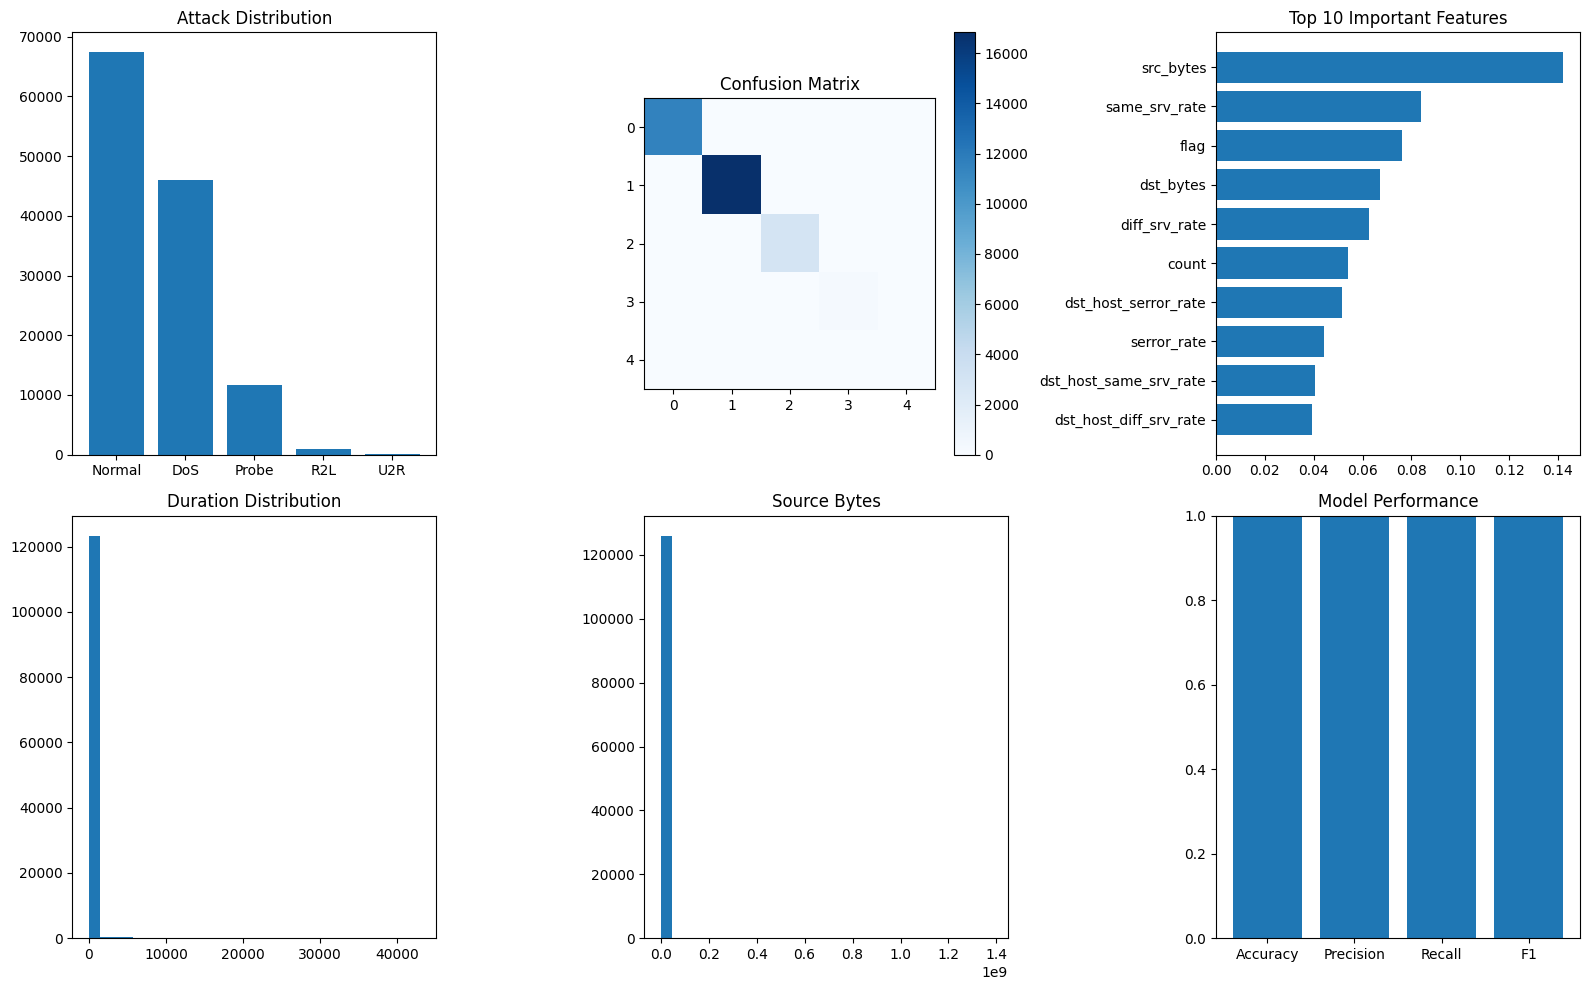



MODEL SUMMARY
Total Records        : 125973
Training Samples     : 94479
Testing Samples      : 31494
Accuracy             : 99.89%
Precision            : 0.9989
Recall               : 0.9989
F1 Score             : 0.9989

Closing Network Intrusion Detection System...


In [6]:
def main():

    print("=" * 70)
    print("      NETWORK INTRUSION DETECTION SYSTEM")
    print("=" * 70)

    # Load Dataset
    df = load_dataset()

    # Preprocess
    (
        X_train,
        X_test,
        y_train,
        y_test,
        scaler,
        encoders,
        target_encoder,
        feature_names
    ) = preprocess_data(df)

    # Train Model
    model = train_model(X_train, y_train)

    # Evaluate
    (
        cm,
        accuracy,
        precision,
        recall,
        f1
    ) = evaluate_model(
        model,
        X_test,
        y_test,
        target_encoder
    )

    # Graphs
    visualize_results(
        df,
        model,
        feature_names,
        cm,
        accuracy,
        precision,
        recall,
        f1
    )

    print("\n")
    print("=" * 70)
    print("MODEL SUMMARY")
    print("=" * 70)

    print(f"Total Records        : {len(df)}")
    print(f"Training Samples     : {len(X_train)}")
    print(f"Testing Samples      : {len(X_test)}")
    print(f"Accuracy             : {accuracy*100:.2f}%")
    print(f"Precision            : {precision:.4f}")
    print(f"Recall               : {recall:.4f}")
    print(f"F1 Score             : {f1:.4f}")

    while True:

        choice = input("\nPredict New Network Packet? (yes/no): ").strip().lower()

        if choice == "yes":

            predict_intrusion(
                model,
                scaler,
                encoders,
                target_encoder,
                feature_names
            )

        else:

            print("\nClosing Network Intrusion Detection System...")
            break


if __name__ == "__main__":
    main()